In [1]:
pip install pandas faker geopy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from geopy.distance import geodesic

df = pd.read_csv("D:/IP_Fraud_Project/data/generate_data.csv")
df['login_time'] = pd.to_datetime(df['login_time'])

In [3]:
df

,user_id,login_time,ip_address,device_id,latitude,longitude,country,city,isp
0,350,2026-02-06 15:01:33,132.28.93.130,6cd8aa78-3bb7-4540-a5f2-781687e3feac,-31.011727,107.454587,Central African Republic,West Leahville,Airtel
1,839,2026-03-01 15:01:07,18.122.249.56,86153b3f-b40d-46ac-affc-92ddfbc414a6,-84.092249,9.422416,Indonesia,Port Johnland,DataCenterISP
2,997,2026-02-26 21:10:06,47.114.108.233,ac82b4ef-7c55-40ea-9ec4-28d2ae7b8a62,32.502208,84.895860,Switzerland,Jordanview,Vodafone
3,629,2026-03-01 18:12:39,180.159.215.175,1c975c7c-8e92-4195-ad4c-c41a580eabba,-71.361560,22.274248,Tanzania,East Jessicashire,Jio
4,549,2026-02-08 04:48:59,203.154.11.236,27e13b43-fc5b-46ad-bf4b-ec0c15a57dab,-19.144507,137.994221,Congo,North Stephanieland,Vodafone
...,...,...,...,...,...,...,...,...,...
9995,5,2026-02-05 15:11:38,181.226.247.7,a9323b9b-d0e7-4d28-9aea-5da5fec05656,-89.057452,81.583376,Seychelles,East Harold,DataCenterISP
9996,683,2026-02-21 08:16:16,125.183.166.172,76a0f866-5a95-469e-9790-468aad4fe816,64.674820,158.021914,Denmark,Brianview,DataCenterISP
9997,549,2026-02-24 19:29:32,62.42.40.81,7de22aa7-3137-49f9-a29a-b76d693251ba,-82.762814,75.553018,Malawi,Mendezfort,Vodafone
9998,870,2026-02-22 20:19:20,95.107.58.121,71668e97-2bc2-43a3-a4aa-95bcc1d5dd17,52.253252,15.181476,Grenada,Sandrabury,Airtel


In [4]:
#Fraud Rule 1 – Multiple Accounts Using Same IP
ip_user_count = df.groupby("ip_address")["user_id"].nunique().reset_index()
ip_user_count.columns = ["ip_address", "unique_users"]

suspicious_ips = ip_user_count[ip_user_count["unique_users"] > 5]

df["multi_account_flag"] = df["ip_address"].isin(
    suspicious_ips["ip_address"]
).astype(int)

In [6]:
ip_user_count
suspicious_ips

,ip_address,unique_users


In [7]:
# Fraud Rule 2 – Impossible Travel

df = df.sort_values(["user_id", "login_time"])

df["impossible_travel_flag"] = 0

for user in df["user_id"].unique():
    
    user_data = df[df["user_id"] == user]
    
    for i in range(len(user_data) - 1):
        
        row1 = user_data.iloc[i]
        row2 = user_data.iloc[i + 1]
        
        distance = geodesic(
            (row1["latitude"], row1["longitude"]),
            (row2["latitude"], row2["longitude"])
        ).km
        
        time_diff = (row2["login_time"] - row1["login_time"]).total_seconds() / 3600
        
        if time_diff > 0:
            speed = distance / time_diff
            
            if speed > 900:
                df.loc[row2.name, "impossible_travel_flag"] = 1

In [8]:
# Fraud Rule 3 – Suspicious ISP (Data Center)

df["vpn_flag"] = df["isp"].apply(
    lambda x: 1 if x == "DataCenterISP" else 0
)

In [9]:
# Fraud Rule 4 – High Login Frequency

ip_counts = df.groupby("ip_address").size().reset_index(name="login_count")

high_freq_ips = ip_counts[ip_counts["login_count"] > 20]

df["frequency_flag"] = df["ip_address"].isin(
    high_freq_ips["ip_address"]
).astype(int)

In [10]:
# Risk Scoring System

def calculate_risk(row):
    score = 0
    
    if row["multi_account_flag"] == 1:
        score += 30
        
    if row["impossible_travel_flag"] == 1:
        score += 40
        
    if row["vpn_flag"] == 1:
        score += 20
        
    if row["frequency_flag"] == 1:
        score += 30
        
    return score

df["risk_score"] = df.apply(calculate_risk, axis=1)

In [11]:
# Risk Classification

def classify_risk(score):
    if score <= 30:
        return "Low"
    elif score <= 60:
        return "Medium"
    else:
        return "High"

df["risk_level"] = df["risk_score"].apply(classify_risk)

In [13]:
# Save Final Fraud Dataset

df.to_csv("D:/IP_Fraud_Project/data/fraud_results.csv", index=False)
print("Fraud Analysis Completed!")

Fraud Analysis Completed!


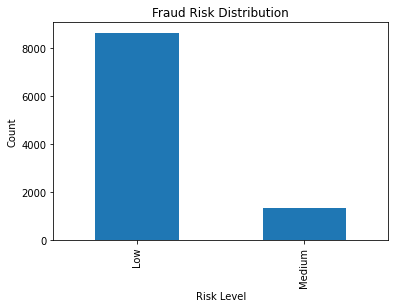

In [14]:
# Simple Visualization

import matplotlib.pyplot as plt

risk_counts = df["risk_level"].value_counts()

risk_counts.plot(kind="bar")
plt.title("Fraud Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

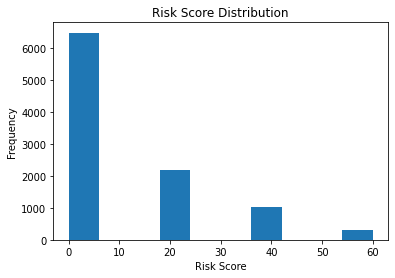

In [15]:
# Risk Score Distribution (Histogram)

plt.figure()
plt.hist(df["risk_score"], bins=10)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Global Styling
import matplotlib.pyplot as plt
import seaborn as sns

# Aesthetic theme
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10,6)
plt.show()

<ipython-input-20-43f2f3078ac1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-20-43f2f3078ac1>:4: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.countplot(


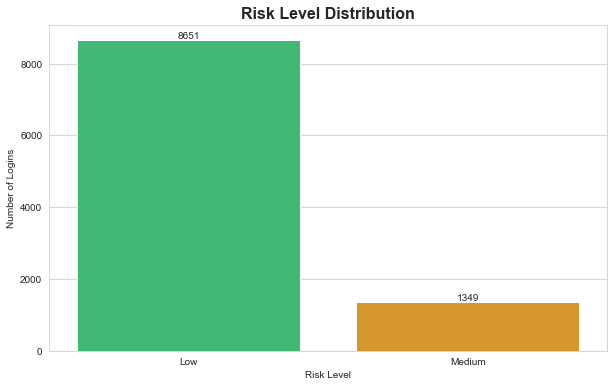

In [20]:
# Risk Level Distribution

plt.figure()
ax = sns.countplot(
    x="risk_level",
    data=df,
    palette=["#2ecc71", "#f39c12", "#e74c3c"]
)

plt.title("Risk Level Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Risk Level")
plt.ylabel("Number of Logins")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

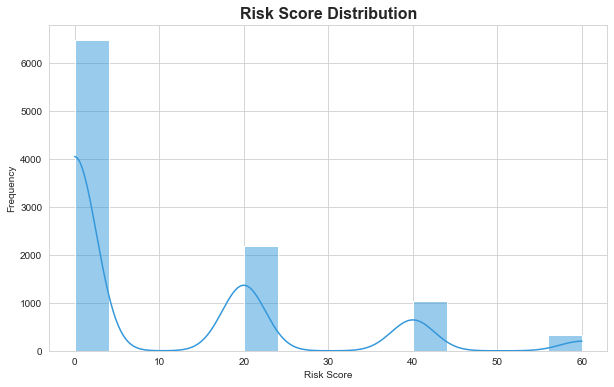

In [21]:
# Risk Score Distribution

plt.figure()
sns.histplot(df["risk_score"], bins=15, kde=True, color="#3498db")

plt.title("Risk Score Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()

In [27]:
print(df["risk_level"].value_counts())

risk_level
Low       8651
Medium    1349
Name: count, dtype: int64


In [37]:
# Top 10 High Risk Countries
top_countries = df[df["risk_level"]=="High"]["country"].value_counts().head(10)

if len(top_countries) > 0:
    plt.figure()
    colors = sns.color_palette("Reds", len(top_countries))
    ax = top_countries.plot(kind="bar", color=colors)

    plt.title("Top 10 High Risk Countries", fontsize=16, fontweight="bold")
    plt.xlabel("Country")
    plt.ylabel("Number of Fraud Cases")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No High Risk Data Found ")

No High Risk Data Found 


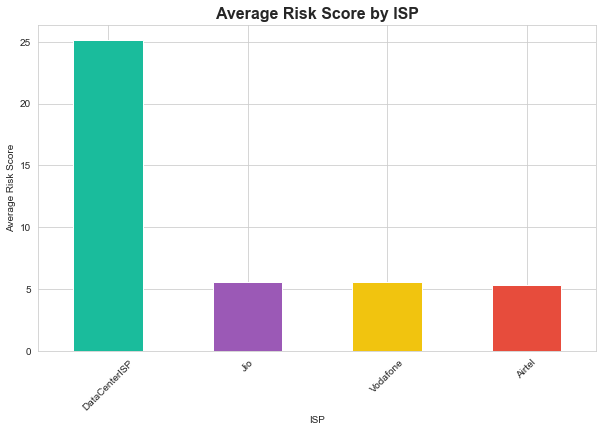

In [ ]:
# ISP Risk Comparison
isp_risk = df.groupby("isp")["risk_score"].mean().sort_values(ascending=False)

plt.figure()
ax = isp_risk.plot(
    kind="bar",
    color=["#1abc9c", "#9b59b6", "#f1c40f", "#e74c3c"]
)

plt.title("Average Risk Score by ISP", fontsize=16, fontweight="bold")
plt.xlabel("ISP")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45)

plt.show()

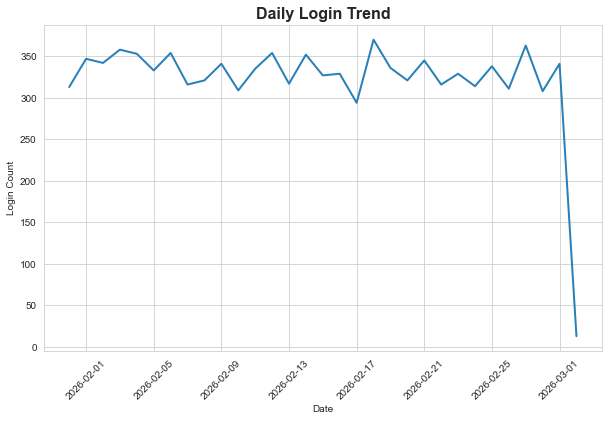

In [38]:
# Daily Login Trend

df["date"] = df["login_time"].dt.date
daily_logins = df.groupby("date").size()

plt.figure()
plt.plot(daily_logins, color="#2980b9", linewidth=2)

plt.title("Daily Login Trend", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Login Count")
plt.xticks(rotation=45)

plt.show()

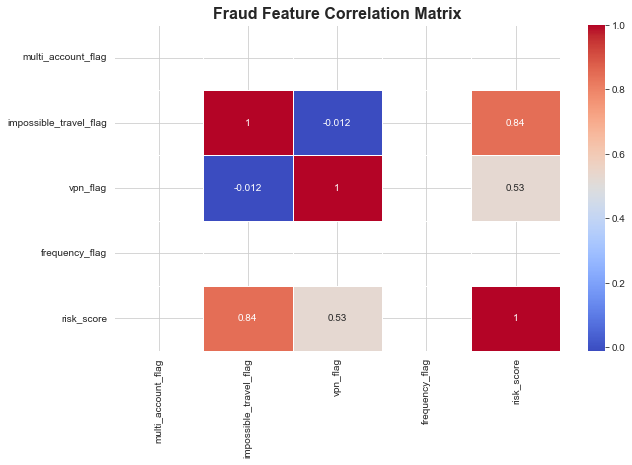

In [40]:
# Correlation Heatmap

fraud_features = df[[
    "multi_account_flag",
    "impossible_travel_flag",
    "vpn_flag",
    "frequency_flag",
    "risk_score"
]]

plt.figure()
sns.heatmap(
    fraud_features.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Fraud Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.show()